Title: PSL_cluster_fut.ipynb

Purpose: Make a clustering of large scale weather patterns with 2015-2024 and 2K warming conditions

This clustering is based on all PSL data (in the analysis we only use PSL data from VRES days, thus this script is old)

Author: Onno Nennecke on 03.06.2025 Modified: 201.03.2026

Input data: 

- PSL Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- kmeans scores: psl_kmeans_score_diff_k.csv
    - This file lies here: /home/onennecke/psl_clustering/psl_kmeans_score_diff_k.csv
- Kmeans score Plot: PSL_cluster_elbow_silhouette
    - This file lies here: /home/onennecke/Code/Figures/
- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc_2.npz


### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
import cftime
# import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc_fut/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 7GB
Dimensions:    (ESM_run: 192, time: 4550, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 36kB 2030-01-01 00:00:00 ... 2054-12-31 00:00:00
  * ESM_run    (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14...
    crs        (time) float64 36kB dask.array<chunksize=(1820,), meta=np.ndarray>
    gridtype   (time) object 36kB dask.array<chunksize=(1820,), meta=np.ndarray>
    ESM        (time, ESM_run) object 7MB dask.array<chunksize=(1820, 3), meta=np.ndarray>
    run        (ESM_run, time) object 7MB dask.array<chunksize=(3, 1820), meta=np.ndarray>
    dayofyear  (time) float64 36kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    psl        (ESM_run, time, lat, lon) float32 7GB dask.array<chunksize=(3, 1820, 40, 50), meta=np.ndarray>

In [4]:
psl = ts_datasets['psl']  # (ESM_run, time, lat, lon)

# Stack spatial dimensions
psl_flat = psl.stack(space=("lat", "lon"))

# Move to (samples, features)
X_new = psl_flat.transpose("ESM_run", "time", "space")

# Combine ESM_run + time into single sample dimension
X_new = X_new.stack(sample=("ESM_run", "time"))

# Convert to numpy
X_new_np = X_new.values

In [8]:
X_new_np.shape

(2000, 873600)

In [5]:
# data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
# labels = data['labels']
# centroids_reshaped = data['centroids_reshaped']

data = np.load('/home/onennecke/psl_clustering/old/reproduced/clustering_results_nbc.npz')

# data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
centroids = data['centroids_reshaped']   # (5, 40, 50)

psl = ts_datasets['psl']   # (ESM_run, time, lat, lon)

print(psl.shape)
print(centroids.shape)

# stack lat/lon
psl_flat = psl.stack(space=("lat", "lon"))
# 2) Transpose so space is LAST
psl_flat = psl_flat.transpose("ESM_run", "time", "space")
print(psl_flat.shape)
# (192, 4550, 2000)

# 3) Stack sample dimension
X_new = psl_flat.stack(sample=("ESM_run", "time"))
# 4) Make sure sample is first
X_new_np = X_new.transpose("sample", "space")

print(X_new_np.shape)
# reshape centroids
centroids_flat = centroids.reshape(centroids.shape[0], -1)

print(centroids_flat.shape)

# X_new = psl_flat.stack(sample=("ESM_run", "time"))
# X_new_np = X_new.values   # (n_samples, 2000)

# print(X_new.shape)
# print(X_new_np.shape)


(192, 4550, 40, 50)
(5, 40, 50)
(192, 4550, 2000)
(873600, 2000)
(5, 2000)


In [6]:
from scipy.spatial.distance import cdist

distances = cdist(X_new_np, centroids_flat)
new_labels = np.argmin(distances, axis=1)

In [7]:


cluster_da = xr.DataArray(
    new_labels,
    coords={"sample": X_new.sample},
    dims=["sample"]
)

cluster_da = cluster_da.unstack("sample")

In [8]:
# True where ALL lat/lon values are NaN
all_nan_mask = psl.isnull().all(dim=("lat", "lon"))

cluster_da = cluster_da.where(~all_nan_mask)

# print("Number of empty maps:", all_nan_mask.sum().item())

In [9]:
cluster_da

<xarray.DataArray (ESM_run: 192, time: 4550)> Size: 7MB
dask.array<where, shape=(192, 4550), dtype=float64, chunksize=(103, 1820), chunktype=numpy.ndarray>
Coordinates:
  * ESM_run    (ESM_run) object 2kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r1...
  * time       (time) object 36kB 2030-01-01 00:00:00 ... 2054-12-31 00:00:00
    crs        (time) float64 36kB dask.array<chunksize=(1820,), meta=np.ndarray>
    gridtype   (time) object 36kB dask.array<chunksize=(1820,), meta=np.ndarray>
    ESM        (time, ESM_run) object 7MB dask.array<chunksize=(1820, 3), meta=np.ndarray>
    run        (ESM_run, time) object 7MB dask.array<chunksize=(3, 1820), meta=np.ndarray>
    dayofyear  (time) float64 36kB dask.array<chunksize=(1820,), meta=np.ndarray>

(array([55073.,     0., 87825.,     0.,     0., 78316.,     0., 74102.,
            0., 54124.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

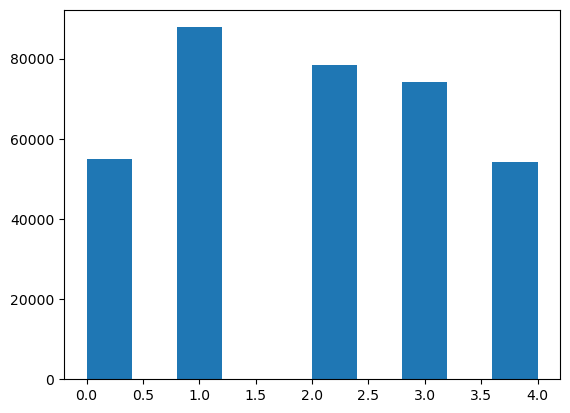

In [10]:
cluster_da.plot.hist()

### Check something probably delete

##### Look how the clusters are seasonaly distributed

In [11]:
# ────────────── 1) Recover time‐coordinates for each “flattened” sample ──────────────
n_ESM = ts_datasets.sizes['ESM_run']  # number of ESM runs
n_times = ts_datasets.sizes['time']    # number of time‐slices
time_coords = ts_datasets['time'].values      # shape = (n_times,), dtype=datetime64

times_repeated = np.tile(time_coords, n_ESM)

len(times_repeated)

873600

In [12]:
# ────────────── 2) Recover ESM‐run coordinates for each “flattened” sample ──────────────
ESM_run = ts_datasets['ESM_run'].values
esm_run_coords = np.repeat(ESM_run, n_times)
esm_run_coords

array(['ACCESS-CM2_r4i1p1f1', 'ACCESS-CM2_r4i1p1f1',
       'ACCESS-CM2_r4i1p1f1', ..., 'UKESM1-0-LL_r14i1p1f2',
       'UKESM1-0-LL_r14i1p1f2', 'UKESM1-0-LL_r14i1p1f2'], dtype='<U23')

In [13]:
n_times

4550

In [14]:
ESM_run.shape

(192,)

In [15]:
# ────────────── 2) Recover ESM‐run coordinates for each “flattened” sample ──────────────
ESMs = ts_datasets['ESM'].values
esm_coords = np.repeat(ESMs[0], n_times)
esm_coords

array([nan, nan, nan, ..., 'UKESM1-0-LL', 'UKESM1-0-LL', 'UKESM1-0-LL'],
      dtype=object)

In [16]:
ts_datasets['ESM'].values[0]

array([nan, nan, nan, nan, 'CESM2', 'CESM2', 'CESM2', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_L

In [17]:
ESMs[0]

array([nan, nan, nan, nan, 'CESM2', 'CESM2', 'CESM2', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE',
       'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_LE', 'CESM2_L

In [18]:
len(esm_run_coords)
n_ESM

192

In [19]:
cluster_da

<xarray.DataArray (ESM_run: 192, time: 4550)> Size: 7MB
dask.array<where, shape=(192, 4550), dtype=float64, chunksize=(103, 1820), chunktype=numpy.ndarray>
Coordinates:
  * ESM_run    (ESM_run) object 2kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r1...
  * time       (time) object 36kB 2030-01-01 00:00:00 ... 2054-12-31 00:00:00
    crs        (time) float64 36kB dask.array<chunksize=(1820,), meta=np.ndarray>
    gridtype   (time) object 36kB dask.array<chunksize=(1820,), meta=np.ndarray>
    ESM        (time, ESM_run) object 7MB dask.array<chunksize=(1820, 3), meta=np.ndarray>
    run        (ESM_run, time) object 7MB dask.array<chunksize=(3, 1820), meta=np.ndarray>
    dayofyear  (time) float64 36kB dask.array<chunksize=(1820,), meta=np.ndarray>

In [20]:
labels_fut = cluster_da.values.flatten()

In [21]:
labels_fut.shape

(873600,)

In [22]:
# Count non na values
non_na_count = np.count_nonzero(~np.isnan(labels_fut))
print(non_na_count)

349440


In [23]:
349440 / 192 / 10

182.0

In [19]:
# data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
data = np.load('/home/onennecke/psl_clustering/old/reproduced/clustering_results_nbc.npz')

labels = data['labels']
labels.shape

(351260,)

In [51]:
351260 / 193 / 10

182.0

In [23]:
esm_coords.shape

(3974880000,)

In [47]:
esm_run_coords

array(['ACCESS-CM2_r4i1p1f1', 'ACCESS-CM2_r4i1p1f1',
       'ACCESS-CM2_r4i1p1f1', ..., 'UKESM1-0-LL_r14i1p1f2',
       'UKESM1-0-LL_r14i1p1f2', 'UKESM1-0-LL_r14i1p1f2'], dtype='<U23')

In [54]:
# ────────────── 2) Build a small DataFrame with (time, cluster) ──────────────

df = pd.DataFrame({
    "time":    times_repeated,
    "cluster": labels_fut,
    "ESM_run": esm_run_coords,
    "ESM":     [entry.split("_")[0] for entry in esm_run_coords]
})
# df

In [55]:
df

,time,cluster,ESM_run,ESM
0,2030-01-01 00:00:00,NaN,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
1,2030-01-02 00:00:00,NaN,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
2,2030-01-03 00:00:00,NaN,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
3,2030-01-04 00:00:00,NaN,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
4,2030-01-05 00:00:00,NaN,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
...,...,...,...,...
873595,2054-12-27 00:00:00,NaN,UKESM1-0-LL_r14i1p1f2,UKESM1-0-LL
873596,2054-12-28 00:00:00,NaN,UKESM1-0-LL_r14i1p1f2,UKESM1-0-LL
873597,2054-12-29 00:00:00,NaN,UKESM1-0-LL_r14i1p1f2,UKESM1-0-LL
873598,2054-12-30 00:00:00,NaN,UKESM1-0-LL_r14i1p1f2,UKESM1-0-LL


In [56]:
# Remove rows where cluster is NaN
df = df.dropna(subset=["cluster"])
df

,time,cluster,ESM_run,ESM
728,2034-01-01 00:00:00,4.0,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
729,2034-01-02 00:00:00,4.0,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
730,2034-01-03 00:00:00,4.0,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
731,2034-01-04 00:00:00,4.0,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
732,2034-01-05 00:00:00,4.0,ACCESS-CM2_r4i1p1f1,ACCESS-CM2
...,...,...,...,...
870865,2039-12-27 00:00:00,1.0,UKESM1-0-LL_r14i1p1f2,UKESM1-0-LL
870866,2039-12-28 00:00:00,1.0,UKESM1-0-LL_r14i1p1f2,UKESM1-0-LL
870867,2039-12-29 00:00:00,1.0,UKESM1-0-LL_r14i1p1f2,UKESM1-0-LL
870868,2039-12-30 00:00:00,1.0,UKESM1-0-LL_r14i1p1f2,UKESM1-0-LL


In [57]:
cluster_counts = df['cluster'].value_counts().sort_index()
total_counts = len(df)
cluster_probabilities = cluster_counts / total_counts
print("Cluster Occurrences:\n", cluster_counts)
print("\nCluster Occurrence Probabilities:\n", cluster_probabilities)

Cluster Occurrences:
 cluster
0.0    55073
1.0    87825
2.0    78316
3.0    74102
4.0    54124
Name: count, dtype: int64

Cluster Occurrence Probabilities:
 cluster
0.0    0.157604
1.0    0.251331
2.0    0.224119
3.0    0.212059
4.0    0.154888
Name: count, dtype: float64


--- 

In [59]:
# ────────────── 3) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
# df["month"]  = pd.DatetimeIndex(df["time"]).month
df["month"]  = [t.month for t in df["time"]]

df["season"] = df["month"].map(month_to_season)
# df


/tmp/ipykernel_2978055/3084951450.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"]  = [t.month for t in df["time"]]
/tmp/ipykernel_2978055/3084951450.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["season"] = df["month"].map(month_to_season)


In [60]:
# ────────────── 4) Count how many samples of each cluster fall in each season ──────────────

# This gives you a table with index = cluster ID, columns = season, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)  
# e.g. monthly_counts.loc[2, "JJA"] is “how many cluster–2 days fall in summer (JJA).”

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)
# Now each row sums to 1, so monthly_frac.loc[i, s] is the fraction of cluster i’s samples in season s.


In [61]:
monthly_frac
# Calculate the sum per month
monthly_sum = monthly_counts.sum(axis=0)
monthly_sum
# Oktober passt
# November passt
# Dezember passt
# Januar passt
# Februar passt


month
1     59520
2     53760
3     59520
10    59520
11    57600
12    59520
dtype: int64

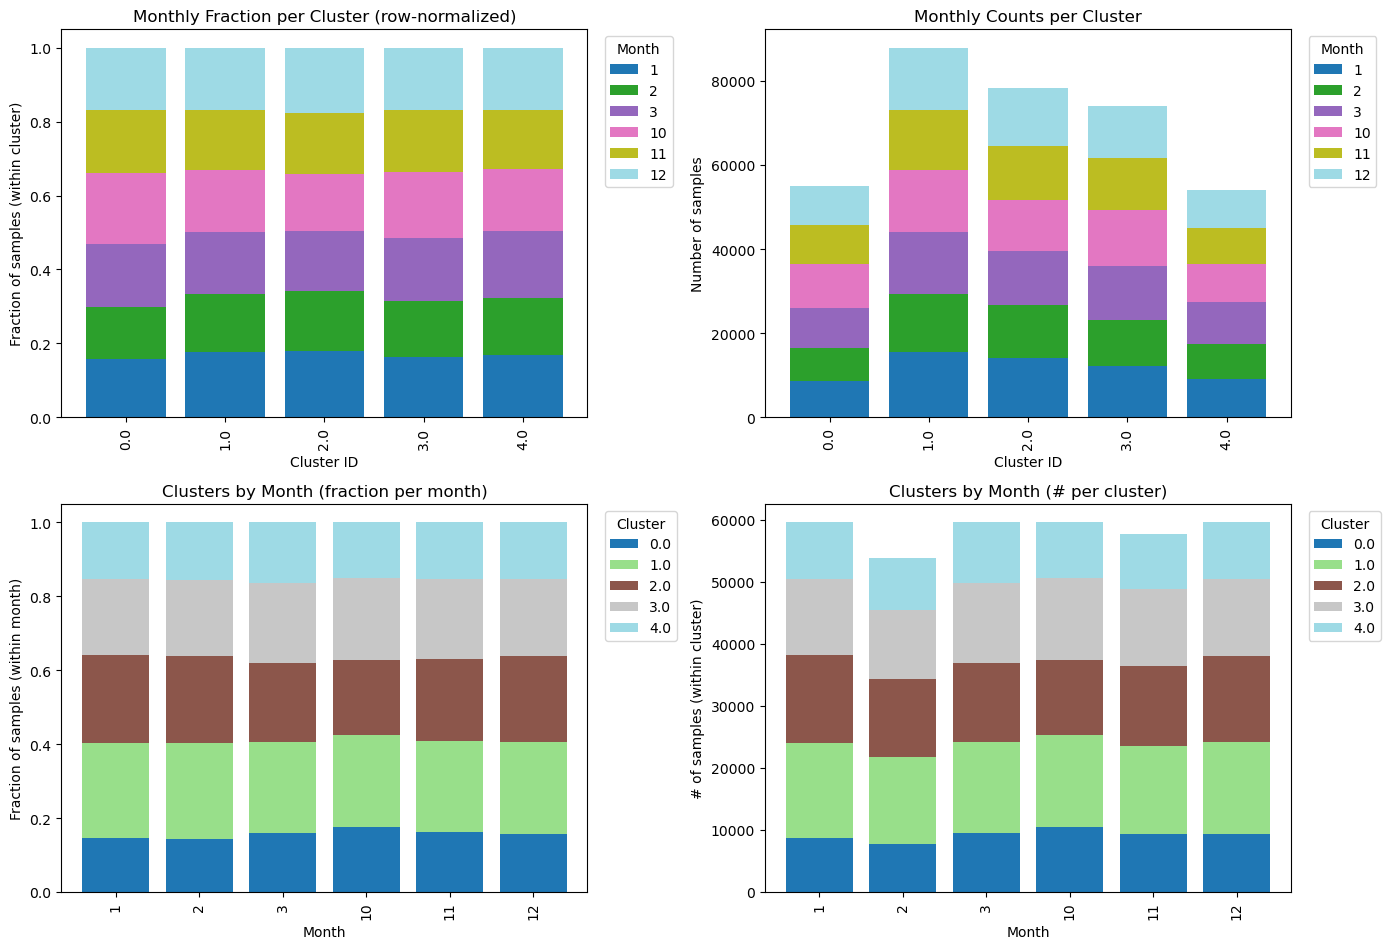

In [62]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# 1) Top‐Left: monthly_frac (clusters on x‐axis, months stacked)
monthly_frac.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="tab20",
    width=0.8
)
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("Fraction of samples (within cluster)")
axes[0].set_title("Monthly Fraction per Cluster (row‐normalized)")
axes[0].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 2) Top‐Right: monthly_counts (clusters on x‐axis, months stacked)
monthly_counts.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    colormap="tab20",
    width=0.8
)
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Monthly Counts per Cluster")
axes[1].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Right: monthly_frac_within_month.T (months on x‐axis, clusters stacked; fraction within month)
monthly_frac_within_month = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

monthly_frac_within_month.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    colormap="tab20",
    width=0.8
)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Fraction of samples (within month)")
axes[2].set_title("Clusters by Month (fraction per month)")
axes[2].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Left: monthly_counts.T (months on x‐axis, clusters stacked; fraction within cluster)
monthly_counts.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[3],
    colormap="tab20",
    width=0.8
)
axes[3].set_xlabel("Month")
axes[3].set_ylabel("# of samples (within cluster)")
axes[3].set_title("Clusters by Month (# per cluster)")
axes[3].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")



# ────────────── D) Adjust layout ──────────────

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.suptitle("Seasonal/Monthly Distribution of Clusters", fontsize=16, y=0.99)
plt.show()

----

### Look at distribution for each ESM

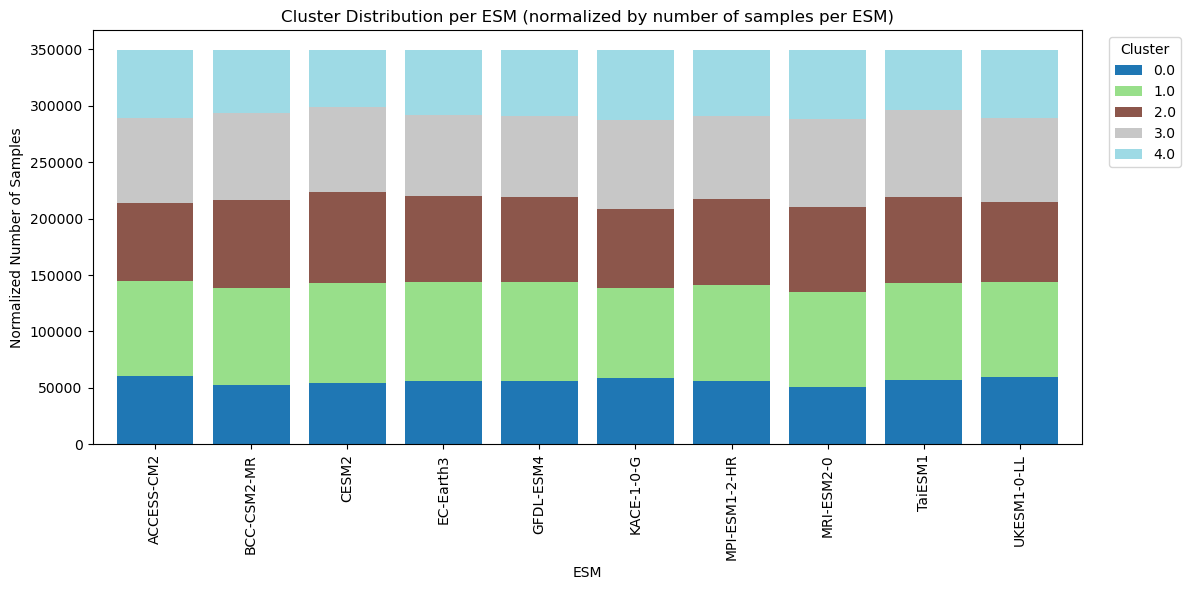

In [63]:
# Make one plot for all ESMs each represented by a stacked barplot normalize by number of samples per ESM
# Calculate the number of samples per ESM
samples_per_esm = df['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(samples_per_esm, axis=0)
esm_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
    width=0.8
)
plt.xlabel("ESM")
plt.ylabel("Normalized Number of Samples")
plt.title("Cluster Distribution per ESM (normalized by number of samples per ESM)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

----

In [64]:
# 1) Unpack sizes & coords
times   = ts_datasets.time           # (1820,)
runs    = ts_datasets.ESM_run        # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels_fut.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times},
    name    = "cluster_id",
)
labels_da

<xarray.DataArray 'cluster_id' (ESM_run: 192, time: 4550)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 1.,  1.,  1., ..., nan, nan, nan],
       [ 2.,  2.,  2., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan]])
Coordinates:
  * ESM_run  (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i1...
  * time     (time) object 36kB 2030-01-01 00:00:00 ... 2054-12-31 00:00:00

In [90]:
labels_da

<xarray.DataArray 'cluster_id' (ESM_run: 192, time: 4550)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 2.,  2.,  0., ..., nan, nan, nan],
       [ 1.,  1.,  1., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan]])
Coordinates:
  * ESM_run  (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1p...
  * time     (time) datetime64[ns] 36kB 2030-01-01 2030-01-02 ... 2054-12-31

In [65]:
encoding = {}

all_vars = {**labels_da.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'ESM_run': {'dtype': 'U23'}}

In [66]:
# Save labels_da
labels_da.to_netcdf('/home/onennecke/psl_clustering/old/reproduced/cluster_labels_fut.nc', encoding=encoding)

In [84]:
labels_da.isel(ESM_run=-2, time=1).values

array(1.)

In [82]:
vmin
vmax

np.float32(67.33102)

/tmp/ipykernel_2978055/1408133032.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


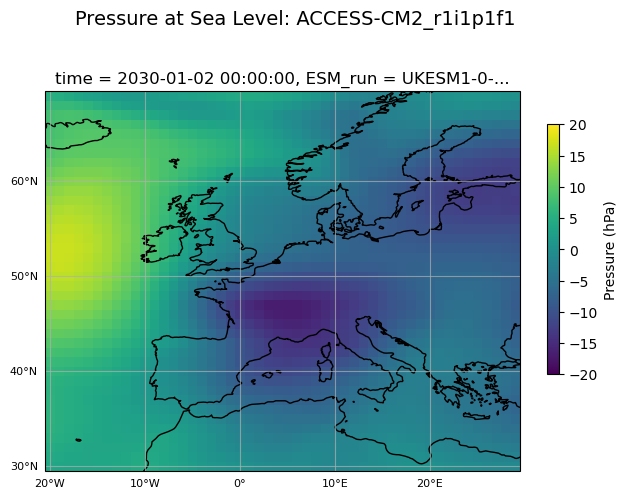

In [67]:
# Select a specific ESM run and one time step
tst = ts_datasets.isel(ESM_run=-1, time=1)


# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = -20 # np.nanmin(ts_datasets['psl'] / 100.0)
vmax = 20 #np.nanmax(ts_datasets['psl'] / 100.0)
# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].min() / 100
# vmax_da = tst['psl'].max() / 100

# cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
# cmap_used = cf.cmap  # capture the colormap for later

# # Force evaluation and extract a scalar
# vmin = float(vmin_da.compute())
# vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    # cmap=cmap_used,
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level: ACCESS-CM2_r1i1p1f1', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


### Select relevant timesteps

In [81]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_fut.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_fut.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_fut.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_fut.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_fut.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_fut.csv')

In [82]:
# Kick every date in April or May
LEE_dat = LEE_dat[(LEE_dat['date_start'].str[5:7] != '04') & (LEE_dat['date_start'].str[5:7] != '05')]
LEE_7 = LEE_7[(LEE_7['date_start'].str[5:7] != '04') & (LEE_7['date_start'].str[5:7] != '05')]
LEE_14 = LEE_14[(LEE_14['date_start'].str[5:7] != '04') & (LEE_14['date_start'].str[5:7] != '05')]
LEE_vl = LEE_vl[(LEE_vl['date_start'].str[5:7] != '04') & (LEE_vl['date_start'].str[5:7] != '05')]



In [83]:

count = 0
for esm in LEE_7['ESM'].unique():
    esm_entries = LEE_7[LEE_7['ESM'] == esm]
    count += len(esm_entries)
    print(esm, len(esm_entries))
    # if len(esm_entries) > 0:
    #     print(esm_entries['time'].values)
    #     print(esm_entries['cluster'].values)
    #     print('-------------------')
print('Total number of entries:', count)

ACCESS-CM2 34
BCC-CSM2-MR 7
CESM2 1386
EC-Earth3 320
GFDL-ESM4 7
KACE-1-0-G 8
MPI-ESM1-2-HR 141
MRI-ESM2-0 39
TaiESM1 6
UKESM1-0-LL 157
Total number of entries: 2105


In [85]:
# Change all esm_run values that contain _LE_LE2_ to _LE2_
labels_da = labels_da.assign_coords(ESM_run=labels_da.ESM_run.str.replace('_LE_LE2', '_LE2'))

In [86]:
# 3) Lookup per‐event cluster
LEE_dat["cluster_at_start"] = [
    labels_da.sel(time=dt, ESM_run=run).item()
    for dt, run in zip(LEE_dat.date_start, LEE_dat.ESM_run)
]
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,cluster_at_start
0,2034-01-25,2034-01-25,2034-01-25,24,24,24,1,1353.514569,1353.514569,0.0,1353.514569,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,25,1.0
1,2034-02-20,2034-02-20,2034-02-20,50,50,50,1,1353.209352,1353.209352,0.0,1353.209352,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,51,1.0
2,2034-02-21,2034-02-21,2034-02-21,51,51,51,1,1340.235724,1340.235724,0.0,1340.235724,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,52,4.0
3,2034-02-22,2034-02-22,2034-02-22,52,52,52,1,1331.586276,1331.586276,0.0,1331.586276,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,53,1.0
4,2034-03-10,2034-03-10,2034-03-10,68,68,68,1,1331.123257,1331.123257,0.0,1331.123257,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,69,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31656,2039-11-21,2039-11-21,2039-11-21,3609,3609,3609,1,1350.057521,1350.057521,0.0,1350.057521,31657,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,325,1.0
31657,2039-11-25,2039-11-25,2039-11-25,3613,3613,3613,1,1328.704265,1328.704265,0.0,1328.704265,31658,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,329,3.0
31658,2039-12-02,2039-12-02,2039-12-02,3620,3620,3620,1,1419.256919,1419.256919,0.0,1419.256919,31659,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,336,1.0
31659,2039-12-09,2039-12-09,2039-12-09,3627,3627,3627,1,1421.787188,1421.787188,0.0,1421.787188,31660,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,343,1.0


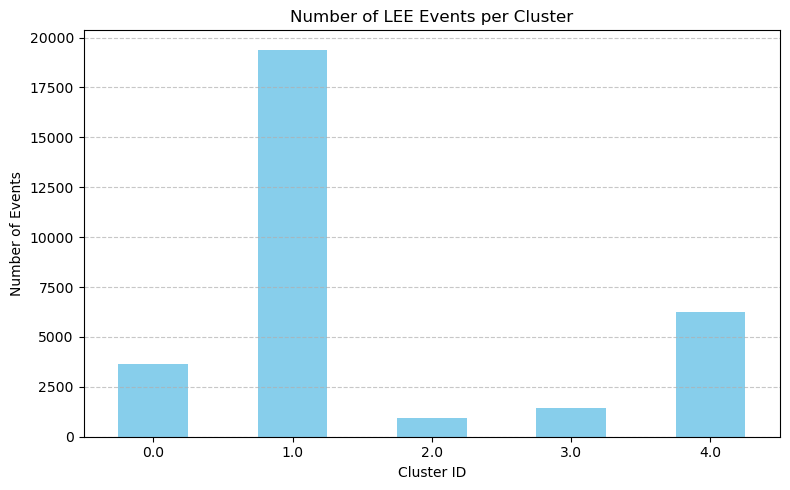

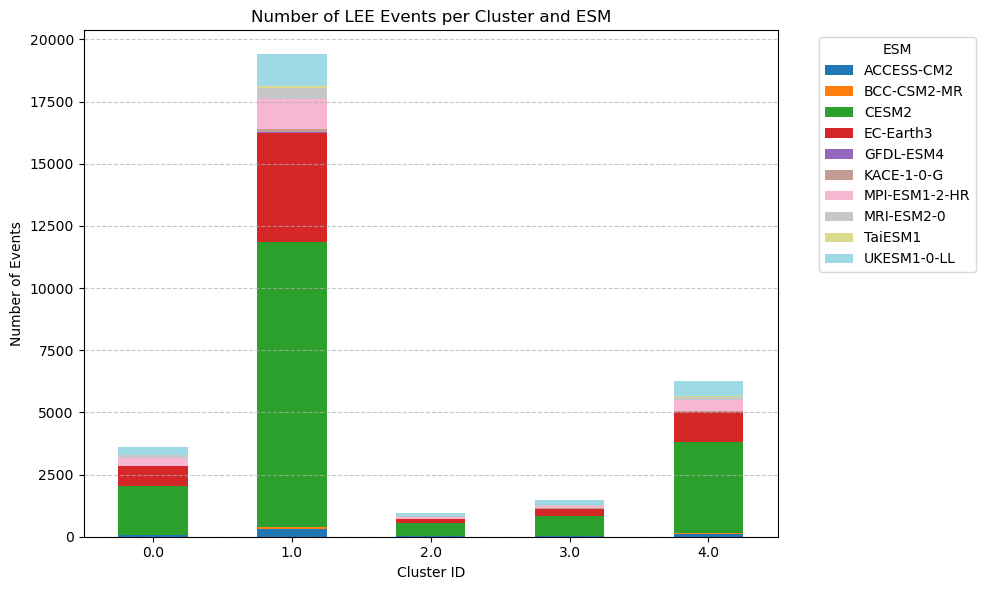

In [87]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_dat['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_dat.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season